<a href="https://colab.research.google.com/github/sharvani1357/Polynomial-Regression/blob/main/polynomial_carprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
df=pd.read_csv("CarPrice_Assignment.csv")

In [ ]:
df[['enginesize', 'price']].head()

,enginesize,price
0,130,13495.0
1,130,16500.0
2,152,16500.0
3,109,13950.0
4,136,17450.0


In [ ]:
print(df[['enginesize', 'price']].isnull().sum())


enginesize    0
price         0
dtype: int64


In [ ]:
x=df[['enginesize']]
y=df['price']

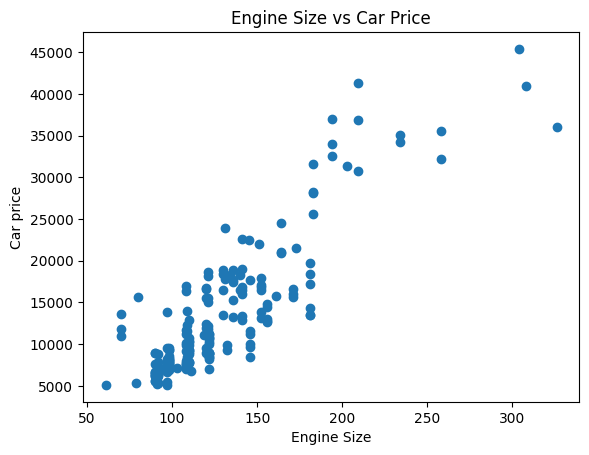

In [ ]:
plt.scatter(x,y)
plt.xlabel("Engine Size")
plt.ylabel("Car price")
plt.title("Engine Size vs Car Price")
plt.show()

In [ ]:
linear_model=LinearRegression()
linear_model.fit(x,y)
y_pred_linear=linear_model.predict(x)

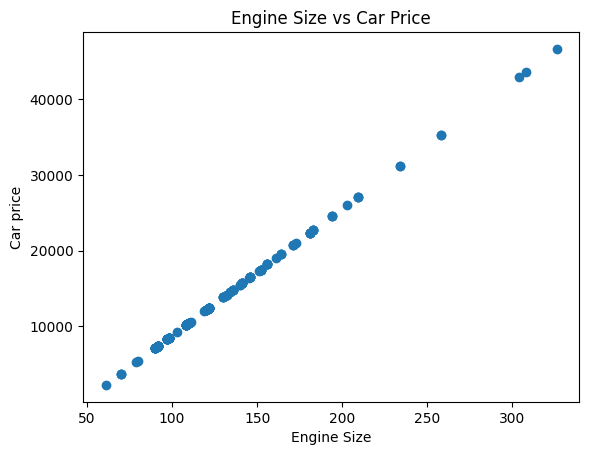

In [ ]:
plt.scatter(x,y_pred_linear)
plt.xlabel("Engine Size")
plt.ylabel("Car price")
plt.title("Engine Size vs Car Price")
plt.show()

In [ ]:
linear_price_200 = linear_model.predict([[200]])
linear_price_200


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([25534.23774749])

In [ ]:
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(x)

poly4_model = LinearRegression()
poly4_model.fit(X_poly4, y)

y_pred_poly4 = poly4_model.predict(X_poly4)



In [ ]:
# Convert to numpy arrays
X_vals = x.values.flatten()
y_linear_vals = y_pred_linear
y_poly_vals = y_pred_poly

# Sort by X
sorted_index = np.argsort(X_vals)

X_sorted = X_vals[sorted_index].reshape(-1,1)
y_linear_sorted = y_linear_vals[sorted_index]
y_poly_sorted = y_poly_vals[sorted_index]


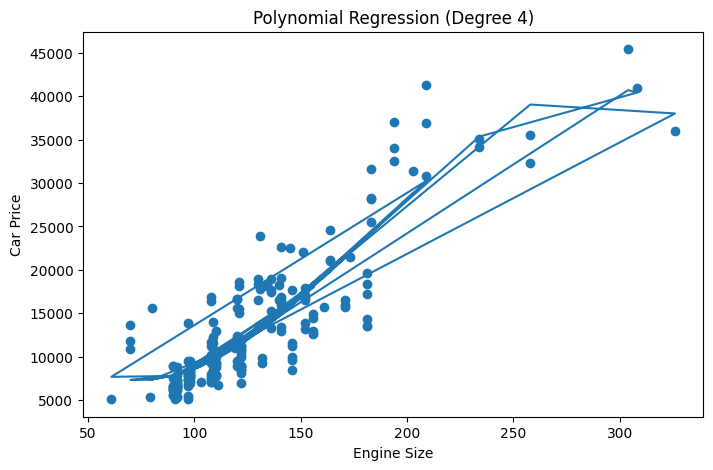

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x, y_pred_poly4)
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Polynomial Regression (Degree 4)")
plt.show()



In [ ]:
poly4_price_200 = poly4_model.predict(poly4.transform([[200]]))
poly4_price_200


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([28205.1318485])

In [ ]:
print("Linear MAE:", mean_absolute_error(y, y_pred_linear))
print("Linear MSE:",mean_squared_error(y, y_pred_linear))
print("Linear RMSE:", np.sqrt(mean_squared_error(y, y_pred_linear)))
print("Poly(4) MAE:", mean_absolute_error(y, y_pred_poly4))
print("Poly(4) RMSE:", np.sqrt(mean_squared_error(y, y_pred_poly4)))
print("Poly(4) MSE:", mean_squared_error(y, y_pred_poly4))


Linear MAE: 2815.022353836411
Linear MSE: 14980261.40555132
Linear RMSE: 3870.4342657576967
Poly(4) MAE: 2692.9296042010114
Poly(4) RMSE: 3618.2051973938833
Poly(4) MSE: 13091408.850448111


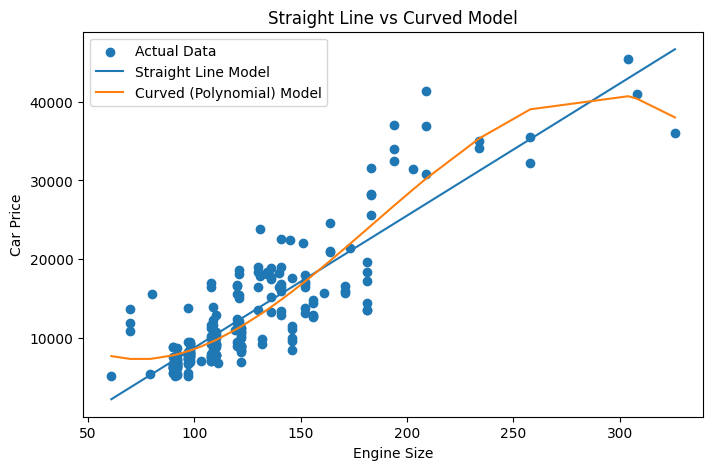

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Actual Data")
plt.plot(X_sorted, y_linear_sorted, label="Straight Line Model")
plt.plot(X_sorted, y_poly_sorted, label="Curved (Polynomial) Model")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Straight Line vs Curved Model")
plt.legend()
plt.show()

